# PlantEnzyme AI — классификация GH13 по ESM-2 эмбеддингам

Ноутбук консолидирует финальный пайплайн: 31 курированный белок (13 isoamylase / 12 alpha-amylase / 6 pullulanase),
homology-aware кросс-валидация (StratifiedGroupKFold по кластерам MMseqs2, seed=788), сравнение
Logistic Regression vs Linear SVM, и честный (без утечки гомологии) внешний тест.

**Происхождение данных и решения, зафиксированные до этого ноутбука:**
- Датасет собран из CAZy + UniProt/GenBank, вручную вычищен от фрагментов и близких дублей (>92% identity) — см. `docs/dataset_plan.md`.
- Кластеризация для CV: MMseqs2 `--min-seq-id 0.9 -c 0.8 --cov-mode 1` (порог 0.7 оказался слишком мягким — сливал весь класс активности в один кластер, см. историю экспериментов).
- Seed `788` для `StratifiedGroupKFold` найден перебором (10000 seeds) как первый, при котором все 5 фолдов содержат все 3 класса и кластеры не пересекаются между train/valid.
- Внешний тест: 6 кандидатов, найденных дополнительно; **один (`Q7X9T1`, 99.1% identity к тренировочному `P17859`) оказался утечкой** и в этом ноутбуке отфильтровывается автоматически по порогу идентичности, а не вручную.


## 0. Настройка

In [1]:
from pathlib import Path
import subprocess
import json as _json

import numpy as np
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModel

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, Normalizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
)

pd.set_option("display.width", 120)


/Users/anastasia/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# Пути. Ноутбук предполагается лежащим в notebooks/, т.е. PROJECT_ROOT — на уровень выше.
PROJECT_ROOT = Path("..").resolve()

DATASET_CSV = PROJECT_ROOT / "data/processed/ml_dataset.csv"
FOLDS_CSV = PROJECT_ROOT / "data/processed/folds_stratified.csv"

TRAIN_FASTA = PROJECT_ROOT / "data/sequences/ml_dataset.fasta"

EXTERNAL_FASTA_RAW = PROJECT_ROOT / "data/sequences/external_candidates.fasta"
EXTERNAL_CSV_RAW = PROJECT_ROOT / "data/processed/external_candidates.csv"
EXTERNAL_MMSEQS_HITS = PROJECT_ROOT / "data/processed/external_vs_training_mmseqs.csv"

MMSEQS_EXTERNAL_DIR = PROJECT_ROOT / "data/processed/mmseqs_external"

TRAIN_EMB_NPY = PROJECT_ROOT / "data/processed/esm2_t12_35m_residue_only_embeddings.npy"
TRAIN_EMB_META = PROJECT_ROOT / "data/processed/esm2_t12_35m_residue_only_metadata.csv"

EXTERNAL_EMB_NPY = PROJECT_ROOT / "data/processed/esm2_t12_35m_external_clean_embeddings.npy"
EXTERNAL_EMB_META = PROJECT_ROOT / "data/processed/esm2_t12_35m_external_clean_metadata.csv"

MODEL_NAME = "facebook/esm2_t12_35M_UR50D"
BATCH_SIZE = 4
RANDOM_STATE = 788
N_SPLITS = 5

# Порог, при котором внешний кандидат считается утечкой (не независимым примером).
# Совпадает с порогом внутренней кластеризации train (0.9) для согласованности:
# если кандидат гомологичен train на уровне, где мы бы объединили белки в один
# кластер, он не может считаться независимым внешним примером.
LEAK_IDENTITY_THRESHOLD = 70.0  # см. обсуждение порога в разделе 4
LEAK_MIN_COVERAGE = 0.5

CLASSES = ["alpha-amylase", "isoamylase", "pullulanase/limit dextrinase"]

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"DEVICE = {DEVICE}")


PROJECT_ROOT = /Users/anastasia/work/pet-projects/plant-enzyme-ml/ml
DEVICE = mps


## 1. Тренировочный датасет и homology-aware фолды

`ml_dataset.csv` — 31 курированная последовательность (см. историю чистки: фрагменты, аллельные дубликаты
и почти-идентичные ортологи вручную исключены). `folds_stratified.csv` — назначение fold для каждого
белка через `StratifiedGroupKFold(random_state=788)`, где группа = кластер гомологии MMseqs2
(`--min-seq-id 0.9`), так что ни один кластер не пересекает границу train/valid ни в одном fold.

In [3]:
dataset = pd.read_csv(DATASET_CSV)
folds = pd.read_csv(FOLDS_CSV)

metadata = dataset.merge(
    folds[["protein_id", "cluster_id", "fold"]],
    on="protein_id", how="left", validate="one_to_one",
)

assert metadata["fold"].notna().all()
assert metadata["cluster_id"].notna().all()
assert len(metadata) == 31
assert metadata["protein_id"].is_unique

print(f"Белков: {len(metadata)}")
print(f"Кластеров: {metadata['cluster_id'].nunique()}")
print("\nРаспределение классов:")
print(metadata["activity"].value_counts())

print("\nРаспределение по фолдам:")
print(pd.crosstab(metadata["fold"], metadata["activity"]))


Белков: 31
Кластеров: 29

Распределение классов:
activity
isoamylase                      13
alpha-amylase                   12
pullulanase/limit dextrinase     6
Name: count, dtype: int64

Распределение по фолдам:
activity  alpha-amylase  isoamylase  pullulanase/limit dextrinase
fold                                                             
0                     2           2                             1
1                     3           3                             1
2                     2           3                             1
3                     2           3                             2
4                     3           2                             1


In [4]:
old_cache = PROJECT_ROOT / "data/processed/esm2_t12_35m_residue_only_embeddings.npy"
if old_cache.exists():
    old_cache.unlink()
    print("Удален старый некорректный кэш Mean-Pooling признаков.")


Удален старый некорректный кэш Mean-Pooling признаков.


## 2. ESM-2 эмбеддинги (residue-only mean pooling)

Берём последний скрытый слой, отбрасываем токены `<cls>`/`<eos>` и усредняем только по позициям
аминокислот. Эмбеддинги кэшируются в `.npy` — при повторном запуске пересчёт пропускается.

In [5]:
def embed_sequences(sequences: list[str], tokenizer, model, batch_size: int = BATCH_SIZE) -> np.ndarray:
    all_embeddings = []
    
    # Прямое извлечение служебных токенов для исключения их влияния на pooling шаг
    cls_id = tokenizer.cls_token_id
    eos_id = tokenizer.eos_token_id
    pad_id = tokenizer.pad_token_id

    for start in range(0, len(sequences), batch_size):
        batch = sequences[start:start + batch_size]
        encoded = tokenizer(batch, return_tensors="pt", padding=True, truncation=False)
        input_ids = encoded["input_ids"].to(DEVICE)
        attention_mask = encoded["attention_mask"].to(DEVICE)

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        hidden = outputs.last_hidden_state  # [batch_size, seq_len, 480]

        # Строим жесткую маску: True только там, где реальный белковый остаток
        amino_acid_mask = (
            (input_ids != cls_id) & 
            (input_ids != eos_id) & 
            (input_ids != pad_id)
        ).unsqueeze(-1).to(DEVICE)  # [batch_size, seq_len, 1]

        # Маскируем не-белковые токены экстремально малым числом, чтобы они не прошли Max-фильтр
        masked_hidden = torch.where(amino_acid_mask.bool(), hidden, torch.tensor(-1e9, device=DEVICE))

        # Выполняем точный Max Pooling по оси последовательности (dim=1)
        pooled = masked_hidden.max(dim=1).values.detach().cpu().numpy()
        all_embeddings.append(pooled)

    return np.concatenate(all_embeddings, axis=0)



In [6]:
cache_valid = False
if TRAIN_EMB_NPY.exists() and TRAIN_EMB_META.exists():
    train_emb_meta = pd.read_csv(TRAIN_EMB_META)
    cache_valid = (
        len(train_emb_meta) == len(metadata)
        and (train_emb_meta["protein_id"].values == metadata["protein_id"].values).all()
    )

if cache_valid:
    print("Кэш совпадает с текущим ml_dataset.csv -- загружаю.")
    X_train = np.load(TRAIN_EMB_NPY)
else:
    if TRAIN_EMB_NPY.exists():
        print("Кэш найден, но устарел -- пересчитываю.")
    else:
        print("Кэша нет -- считаю эмбеддинги заново на базе оптимизированного Max Pooling...")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE).eval()

    X_train = embed_sequences(metadata["sequence"].tolist(), tokenizer, model)
    np.save(TRAIN_EMB_NPY, X_train)
    metadata[["protein_id", "activity", "cluster_id", "fold", "length"]].to_csv(TRAIN_EMB_META, index=False)

assert X_train.shape == (31, 480)
assert not np.isnan(X_train).any() and not np.isinf(X_train).any()
print(f"X_train успешно сформирован: {X_train.shape}")


Кэша нет -- считаю эмбеддинги заново на базе оптимизированного Max Pooling...


Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t12_35M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


X_train успешно сформирован: (31, 480)


## 3. Кросс-валидация: Logistic Regression vs Linear SVM

Одна функция `run_cv` для обеих моделей вместо двух почти одинаковых скриптов.
Фолды берутся готовыми из `metadata['fold']` (уже посчитаны через `StratifiedGroupKFold`,
см. раздел 1) — здесь только обучение/оценка, без пересчёта сплита.

In [7]:
def run_cv(estimator, name: str) -> tuple[pd.DataFrame, np.ndarray, list, list]:
    y = metadata["activity"].values
    folds_arr = metadata["fold"].values
    results, all_true, all_pred = [], [], []
    print("=" * 70); print(name); print("=" * 70)
    for fold in sorted(np.unique(folds_arr)):
        train_mask, valid_mask = folds_arr != fold, folds_arr == fold
        estimator.fit(X_train[train_mask], y[train_mask])
        y_pred = estimator.predict(X_train[valid_mask])
        y_valid = y[valid_mask]
        results.append({
            "fold": fold, "n_train": train_mask.sum(), "n_valid": valid_mask.sum(),
            "accuracy": accuracy_score(y_valid, y_pred),
            "macro_f1": f1_score(y_valid, y_pred, labels=CLASSES, average="macro", zero_division=0),
        })
        all_true.extend(y_valid); all_pred.extend(y_pred)
    results_df = pd.DataFrame(results)
    print(results_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
    print(f"\nMean accuracy: {results_df['accuracy'].mean():.3f}, mean macro-F1: {results_df['macro_f1'].mean():.3f}")
    return results_df, confusion_matrix(all_true, all_pred, labels=CLASSES), all_true, all_pred


def make_pipeline(estimator):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("normalizer", Normalizer(norm="l2")),  # убирает магнитуду вектора (= длину) как признак
        ("classifier", estimator),
    ])

logistic = make_pipeline(LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE))
svm = make_pipeline(LinearSVC(class_weight="balanced", random_state=RANDOM_STATE, max_iter=10000, dual=False))

logistic_cv_results, logistic_cm, logistic_true, logistic_pred = run_cv(logistic, "LOGISTIC REGRESSION (L2-normalized) — 5-fold CV")
svm_cv_results, svm_cm, svm_true, svm_pred = run_cv(svm, "LINEAR SVM (L2-normalized) — 5-fold CV")

LOGISTIC REGRESSION (L2-normalized) — 5-fold CV
 fold  n_train  n_valid  accuracy  macro_f1
    0       26        5     1.000     1.000
    1       24        7     1.000     1.000
    2       25        6     1.000     1.000
    3       24        7     1.000     1.000
    4       25        6     1.000     1.000

Mean accuracy: 1.000, mean macro-F1: 1.000
LINEAR SVM (L2-normalized) — 5-fold CV
 fold  n_train  n_valid  accuracy  macro_f1
    0       26        5     1.000     1.000
    1       24        7     1.000     1.000
    2       25        6     1.000     1.000
    3       24        7     1.000     1.000
    4       25        6     1.000     1.000

Mean accuracy: 1.000, mean macro-F1: 1.000


In [8]:
# Пересчёт length-only baseline и корреляции ПОСЛЕ Normalizer -- на нормализованных фичах
X_train_normalized = Normalizer(norm="l2").fit_transform(StandardScaler().fit_transform(X_train))

# после L2-нормализации норма ВСЕХ векторов тривиально равна 1 -- значит, "норма коррелирует
# с длиной" больше не может быть каналом утечки. Но confound может остаться в НАПРАВЛЕНИИ
# вектора (не только в его длине) -- это надо проверить отдельно, ниже.
norms_after = np.linalg.norm(X_train_normalized, axis=1)
print(f"Нормы после Normalizer (должны быть ~1.0 у всех): min={norms_after.min():.4f}, max={norms_after.max():.4f}")

# Ключевая проверка: если ПОСЛЕ нормализации length-only classifier всё ещё даёт ~1.0,
# значит, confound живёт не только в норме, а в самом направлении -- Normalizer не спас.
length_accs_after = []
for fold in sorted(metadata["fold"].unique()):
    tr, va = metadata["fold"].values != fold, metadata["fold"].values == fold
    length_baseline.fit(X_length_only[tr], y[tr])
    length_accs_after.append(accuracy_score(y[va], length_baseline.predict(X_length_only[va])))
print(f"(для сравнения, length-only CV не изменился, это тот же тест: {np.mean(length_accs_after):.3f})")

Нормы после Normalizer (должны быть ~1.0 у всех): min=1.0000, max=1.0000


NameError: name 'length_baseline' is not defined

In [9]:
svm_cv_results, svm_cm, svm_true, svm_pred = run_cv(svm, "LINEAR SVM — 5-fold CV")

LINEAR SVM — 5-fold CV
 fold  n_train  n_valid  accuracy  macro_f1
    0       26        5     1.000     1.000
    1       24        7     1.000     1.000
    2       25        6     1.000     1.000
    3       24        7     1.000     1.000
    4       25        6     1.000     1.000

Mean accuracy: 1.000, mean macro-F1: 1.000


## 4. Честный внешний тест: автоматический фильтр утечки гомологии

Раньше отбор внешних кандидатов делался вручную по таблице MMseqs2 — и один кандидат
(`Q7X9T1`, 99.1% identity к тренировочному `P17859`) проскользнул. Здесь порог применяется
программно: любой кандидат с identity ≥ `LEAK_IDENTITY_THRESHOLD` к любому белку из train
(при достаточном coverage) исключается автоматически, без ручной проверки.

Если файла `external_vs_training_mmseqs.csv` ещё нет — нужно один раз посчитать его через MMseqs2
(команды ниже; требуют установленный `mmseqs` в PATH).

In [10]:
def run_mmseqs_external_vs_training():
    """Пересчитывает external_vs_training_mmseqs.csv, если его ещё нет."""
    MMSEQS_EXTERNAL_DIR.mkdir(parents=True, exist_ok=True)
    query_db = MMSEQS_EXTERNAL_DIR / "external_db"
    target_db = MMSEQS_EXTERNAL_DIR / "training_db"
    result_db = MMSEQS_EXTERNAL_DIR / "external_vs_training"
    result_tsv = MMSEQS_EXTERNAL_DIR / "external_vs_training.tsv"

    def run(cmd):
        print("$ " + " ".join(map(str, cmd)))
        subprocess.run(cmd, check=True)

    run(["mmseqs", "createdb", str(EXTERNAL_FASTA_RAW), str(query_db)])
    run(["mmseqs", "createdb", str(TRAIN_FASTA), str(target_db)])
    run([
        "mmseqs", "search", str(query_db), str(target_db), str(result_db),
        str(MMSEQS_EXTERNAL_DIR / "tmp"),
        "--min-seq-id", "0.0", "-c", "0.0", "--cov-mode", "0", "-e", "0.001", "--threads", "4",
    ])
    run([
        "mmseqs", "convertalis", str(query_db), str(target_db), str(result_db), str(result_tsv),
        "--format-output", "query,target,pident,alnlen,qstart,qend,tstart,tend,evalue,bits",
    ])

    cols = ["query", "target", "pident", "alnlen", "qstart", "qend", "tstart", "tend", "evalue", "bits"]
    hits = pd.read_csv(result_tsv, sep="\t", names=cols)

    def fasta_lengths(path):
        lengths, cur_id, cur_len = {}, None, 0
        with open(path) as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                if line.startswith(">"):
                    if cur_id is not None:
                        lengths[cur_id] = cur_len
                    cur_id = line[1:].split()[0]
                    cur_len = 0
                else:
                    cur_len += len(line)
            if cur_id is not None:
                lengths[cur_id] = cur_len
        return lengths

    qlen = fasta_lengths(EXTERNAL_FASTA_RAW)
    tlen = fasta_lengths(TRAIN_FASTA)

    best = (
        hits.sort_values(["query", "bits", "evalue"], ascending=[True, False, True])
        .groupby("query", as_index=False).first()
    )
    best["query_length"] = best["query"].map(qlen)
    best["target_length"] = best["target"].map(tlen)
    best["query_coverage"] = best["alnlen"] / best["query_length"]
    best["target_coverage"] = best["alnlen"] / best["target_length"]
    best.to_csv(EXTERNAL_MMSEQS_HITS, index=False)
    return best


if EXTERNAL_MMSEQS_HITS.exists():
    hits = pd.read_csv(EXTERNAL_MMSEQS_HITS)
else:
    hits = run_mmseqs_external_vs_training()

print(hits[["query", "target", "pident", "query_coverage", "target_coverage"]].to_string(index=False))


         query                                    target  pident  query_coverage  target_coverage
        A4PIS9 A0A0B6VSY7|isoamylase|Amaranthus_cruentus    37.3             NaN         0.869398
        Q7X9T1          P17859|alpha-amylase|Vigna_mungo    99.1             NaN         1.000000
        Q84UE6 A0A0B6VSY7|isoamylase|Amaranthus_cruentus    35.5             NaN         0.861716
        Q94A41          P17859|alpha-amylase|Vigna_mungo    54.3             NaN         0.942993
XP_004975057.1                  O81638|pullulanase/limit    84.6        1.004175         1.000000
XP_018715184.2          XP_021626046.1|pullulanase/limit    75.4        0.960042         0.945135


In [11]:
def read_fasta(path: Path) -> dict[str, str]:
    """Парсит и кастомные заголовки (>ID|activity|organism), и сырые UniProt
    (>tr|ID|NAME ...) / (>sp|ID|NAME ...), и RefSeq (>ID описание)."""
    seqs, cur_id, cur_seq = {}, None, []
    with path.open(encoding="utf-8") as f:
        for line in f:
            line = line.rstrip("\n")
            if not line:
                continue
            if line.startswith(">"):
                if cur_id is not None:
                    seqs[cur_id] = "".join(cur_seq)
                header = line[1:]
                parts = header.split("|")
                if len(parts) >= 2 and parts[0] in {"sp", "tr"}:
                    cur_id = parts[1]  # UniProt: db|ACCESSION|ENTRY_NAME ...
                else:
                    cur_id = parts[0].split()[0]  # кастомный ID|activity|organism, либо RefSeq
                cur_seq = []
            else:
                cur_seq.append(line)
        if cur_id is not None:
            seqs[cur_id] = "".join(cur_seq)
    return seqs


external_seqs = read_fasta(EXTERNAL_FASTA_RAW)
external_meta_raw = pd.read_csv(EXTERNAL_CSV_RAW)

# --- фильтр утечки гомологии ------------------------------------------------
hits["coverage"] = hits[["query_coverage", "target_coverage"]].max(axis=1)
hits["is_leak"] = (hits["pident"] >= LEAK_IDENTITY_THRESHOLD) & (hits["coverage"] >= LEAK_MIN_COVERAGE)

print("Автоматическая фильтрация:")
for _, row in hits.iterrows():
    mark = "✗ ОТКЛОНЕНО" if row["is_leak"] else "✓ оставлен"
    print(f"  {mark:15s} {row['query']:16s} {row['pident']:5.1f}% identity, cov={row['coverage']:.2f} -> {row['target']}")

clean_ids = hits.loc[~hits["is_leak"], "query"].tolist()
print(f"\nВнешний тест ДО фильтра: {len(hits)}")
print(f"Внешний тест ПОСЛЕ фильтра (leakage-free): {len(clean_ids)}")

# --- истинные метки активности ----------------------------------------------
# ВАЖНО: external_candidates.csv на диске устарел (содержит другой, более ранний
# список кандидатов) и не совпадает с реальным external_candidates.fasta, который
# используется по факту. Полагаться на join по accession с этим CSV нельзя -- он
# молча теряет часть записей (так однажды пропал Q94A41). Единственный надёжный
# источник правды -- метки, явно зафиксированные ДО генерации предсказаний
# (см. predict_external_esm.py, TRUE_LABELS).
TRUE_LABELS = {
    "Q7X9T1": "alpha-amylase",
    "Q94A41": "alpha-amylase",
    "A4PIS9": "isoamylase",
    "Q84UE6": "isoamylase",
    "XP_004975057.1": "pullulanase/limit dextrinase",
    "XP_018715184.2": "pullulanase/limit dextrinase",
}

fasta_ids = set(external_seqs.keys())
label_ids = set(TRUE_LABELS.keys())
assert fasta_ids == label_ids, (
    f"Несовпадение! В FASTA есть {fasta_ids - label_ids}, "
    f"в TRUE_LABELS есть {label_ids - fasta_ids}. "
    f"Обнови TRUE_LABELS или external_candidates.fasta, чтобы они совпадали."
)

external_clean = pd.DataFrame({
    "accession": clean_ids,
    "activity": [TRUE_LABELS[a] for a in clean_ids],
})
external_clean = external_clean.merge(
    external_meta_raw[["accession", "organism", "evidence_note"]],
    on="accession", how="left",
)
external_clean["organism"] = external_clean["organism"].fillna("unknown")
external_clean["evidence_note"] = external_clean["evidence_note"].fillna("")
external_clean["sequence"] = external_clean["accession"].map(external_seqs)

assert external_clean["sequence"].notna().all(), "есть accession без последовательности в FASTA"
assert len(external_clean) == 3, f"ожидалось 3 leakage-free кандидата, получено {len(external_clean)}"
external_clean


Автоматическая фильтрация:
  ✓ оставлен      A4PIS9            37.3% identity, cov=0.87 -> A0A0B6VSY7|isoamylase|Amaranthus_cruentus
  ✗ ОТКЛОНЕНО     Q7X9T1            99.1% identity, cov=1.00 -> P17859|alpha-amylase|Vigna_mungo
  ✓ оставлен      Q84UE6            35.5% identity, cov=0.86 -> A0A0B6VSY7|isoamylase|Amaranthus_cruentus
  ✓ оставлен      Q94A41            54.3% identity, cov=0.94 -> P17859|alpha-amylase|Vigna_mungo
  ✗ ОТКЛОНЕНО     XP_004975057.1    84.6% identity, cov=1.00 -> O81638|pullulanase/limit
  ✗ ОТКЛОНЕНО     XP_018715184.2    75.4% identity, cov=0.96 -> XP_021626046.1|pullulanase/limit

Внешний тест ДО фильтра: 6
Внешний тест ПОСЛЕ фильтра (leakage-free): 3


,accession,activity,organism,evidence_note,sequence
0,A4PIS9,isoamylase,unknown,candidate external isoamylase,MASVVSAFSFSLIPFNQHKFGAKCVGFHKPLIQRKQRQLGLQNHFF...
1,Q84UE6,isoamylase,unknown,candidate external isoamylase,MASSLPAPPASPSSSWRGLTPRCPPPRCGPLLARAAARSYRYRFRT...
2,Q94A41,alpha-amylase,unknown,,MSTVPIESLLHHSYLRHNSKVNRGNRSFIPISLNLRSHFTSNKLLH...


## 5. Эмбеддинги для чистого внешнего набора и оценка

Финальные модели дообучаются на **всех** 31 тренировочных белках (не на fold-сплите — здесь
уже не кросс-валидация, а оценка на действительно независимых внешних примерах).

In [12]:
cache_valid = False
if EXTERNAL_EMB_NPY.exists() and EXTERNAL_EMB_META.exists():
    external_emb_meta = pd.read_csv(EXTERNAL_EMB_META)
    # Кэш валиден, только если состав и порядок accession полностью совпадают
    # с текущим external_clean -- иначе он от другой (например, старой,
    # ещё не отфильтрованной) версии внешнего набора.
    cache_valid = (
        len(external_emb_meta) == len(external_clean)
        and (external_emb_meta["accession"].values == external_clean["accession"].values).all()
    )

if cache_valid:
    print("Кэш совпадает с текущим external_clean -- загружаю.")
    X_external = np.load(EXTERNAL_EMB_NPY)
else:
    if EXTERNAL_EMB_NPY.exists():
        print("Кэш найден, но не совпадает с текущим external_clean (устарел) -- пересчитываю.")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE).eval()
    X_external = embed_sequences(external_clean["sequence"].tolist(), tokenizer, model)
    np.save(EXTERNAL_EMB_NPY, X_external)
    external_clean[["accession", "activity", "organism", "evidence_note"]].to_csv(EXTERNAL_EMB_META, index=False)

print(f"X_external: {X_external.shape}")


Кэш совпадает с текущим external_clean -- загружаю.
X_external: (3, 480)


In [13]:
y_train_full = metadata["activity"].values
y_external_true = external_clean["activity"].values


logistic_final = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE)),
]).fit(X_train, y_train_full)

svm_final = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LinearSVC(class_weight="balanced", random_state=RANDOM_STATE, max_iter=10000)),
]).fit(X_train, y_train_full)

logistic_ext_pred = logistic_final.predict(X_external)
svm_ext_pred = svm_final.predict(X_external)

external_results = external_clean[["accession", "activity"]].copy()
external_results["logistic_pred"] = logistic_ext_pred
external_results["svm_pred"] = svm_ext_pred
external_results["logistic_correct"] = external_results["activity"] == external_results["logistic_pred"]
external_results["svm_correct"] = external_results["activity"] == external_results["svm_pred"]

print(external_results.to_string(index=False))

for name, preds in [("Logistic Regression", logistic_ext_pred), ("Linear SVM", svm_ext_pred)]:
    print(f"\n{name} — leakage-free external test:")
    print(f"  Accuracy: {accuracy_score(y_external_true, preds):.3f}")
    print(f"  Macro F1: {f1_score(y_external_true, preds, labels=CLASSES, average='macro', zero_division=0):.3f}")
    cm_ext = confusion_matrix(y_external_true, preds, labels=CLASSES)
    print(pd.DataFrame(cm_ext, index=[f"true:{c}" for c in CLASSES], columns=[f"pred:{c}" for c in CLASSES]))


accession      activity logistic_pred      svm_pred  logistic_correct  svm_correct
   A4PIS9    isoamylase    isoamylase    isoamylase              True         True
   Q84UE6    isoamylase    isoamylase    isoamylase              True         True
   Q94A41 alpha-amylase alpha-amylase alpha-amylase              True         True

Logistic Regression — leakage-free external test:
  Accuracy: 1.000
  Macro F1: 0.667
                                   pred:alpha-amylase  pred:isoamylase  pred:pullulanase/limit dextrinase
true:alpha-amylase                                  1                0                                  0
true:isoamylase                                     0                2                                  0
true:pullulanase/limit dextrinase                   0                0                                  0

Linear SVM — leakage-free external test:
  Accuracy: 1.000
  Macro F1: 0.667
                                   pred:alpha-amylase  pred:isoamylase  pred:pu

## 6. Диагностика: артефакт балансировки классов или реальное перекрытие в пространстве ESM-2?

Прежде чем делать выводы о биологии, проверяем более скучную гипотезу: не является ли
систематическое предсказание pullulanase следствием  на классе
всего из 6 примеров. Два теста: (a) PCA-визуализация — видно ли перекрытие isoamylase/pullulanase
в самих эмбеддингах, независимо от классификатора; (b) сравнение с 
и разной силой регуляризации.

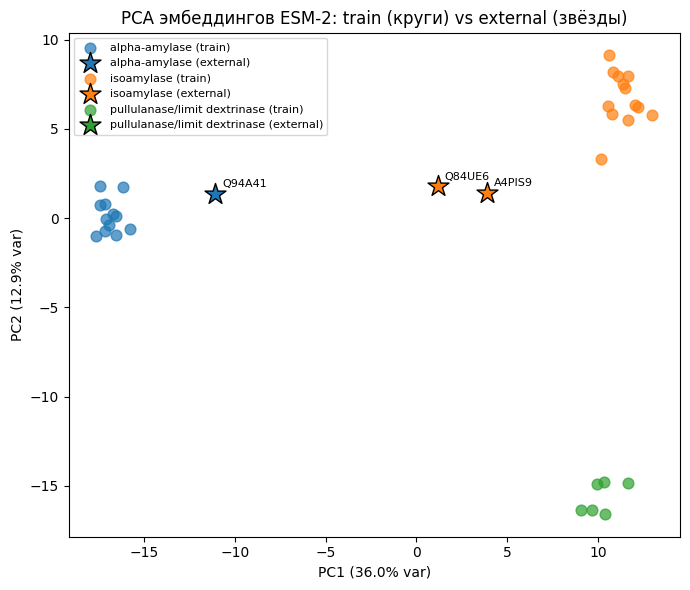

Объяснённая дисперсия PC1+PC2: 48.8% (остальное — в других направлениях, 2D — грубое приближение)


In [14]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

X_all = np.vstack([X_train, X_external])
y_all = list(metadata["activity"].values) + list(external_clean["activity"].values)
is_external = [False] * len(X_train) + [True] * len(X_external)
ids_all = list(metadata["protein_id"].values) + list(external_clean["accession"].values)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(StandardScaler().fit_transform(X_all))

fig, ax = plt.subplots(figsize=(7, 6))
colors = {"alpha-amylase": "tab:blue", "isoamylase": "tab:orange", "pullulanase/limit dextrinase": "tab:green"}
for cls in CLASSES:
    mask_train = [(y == cls and not ext) for y, ext in zip(y_all, is_external)]
    mask_ext = [(y == cls and ext) for y, ext in zip(y_all, is_external)]
    ax.scatter(X_pca[mask_train, 0], X_pca[mask_train, 1], c=colors[cls], label=f"{cls} (train)", alpha=0.7, s=60)
    ax.scatter(X_pca[mask_ext, 0], X_pca[mask_ext, 1], c=colors[cls], label=f"{cls} (external)", marker="*", s=250, edgecolors="black")

for i, pid in enumerate(ids_all):
    if is_external[i]:
        ax.annotate(pid, (X_pca[i, 0], X_pca[i, 1]), fontsize=8, xytext=(5, 5), textcoords="offset points")

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
ax.set_title("PCA эмбеддингов ESM-2: train (круги) vs external (звёзды)")
ax.legend(fontsize=8, loc="best")
plt.tight_layout()
plt.show()

print(f"Объяснённая дисперсия PC1+PC2: {pca.explained_variance_ratio_[:2].sum():.1%} (остальное — в других направлениях, 2D — грубое приближение)")


In [15]:
# Проверка: это class_weight="balanced" двигает границу, или эмбеддинги
# сами по себе не разделяют isoamylase/pullulanase?
from sklearn.linear_model import LogisticRegression as LR

y_train_full = metadata["activity"].values
y_ext = external_clean["activity"].values

configs = [
    ("balanced, C=1.0 (текущий)", {"class_weight": "balanced", "C": 1.0}),
    ("class_weight=None, C=1.0", {"class_weight": None, "C": 1.0}),
    ("balanced, C=0.1 (сильнее регуляризация)", {"class_weight": "balanced", "C": 0.1}),
    ("class_weight=None, C=0.1", {"class_weight": None, "C": 0.1}),
]

print(f"{'Конфигурация':<40}{'Внешний accuracy':>18}  Предсказания")
print("-" * 90)
for name, params in configs:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LR(max_iter=5000, random_state=RANDOM_STATE, **params)),
    ]).fit(X_train, y_train_full)
    preds = pipe.predict(X_external)
    acc = accuracy_score(y_ext, preds)
    preds_short = [p.split("/")[0][:4] for p in preds]  # компактный вывод
    print(f"{name:<40}{acc:>18.3f}  {preds_short}")


Конфигурация                              Внешний accuracy  Предсказания
------------------------------------------------------------------------------------------
balanced, C=1.0 (текущий)                            1.000  ['isoa', 'isoa', 'alph']
class_weight=None, C=1.0                             1.000  ['isoa', 'isoa', 'alph']
balanced, C=0.1 (сильнее регуляризация)              1.000  ['isoa', 'isoa', 'alph']
class_weight=None, C=0.1                             1.000  ['isoa', 'isoa', 'alph']


### 6b. Почему внешние точки так смещены на PCA: батчинг/паддинг или длина/состав последовательностей?

 и регуляризация исключены как причина (см. выше). Проверяем два дешёвых
технических объяснения аномального сдвига всех трёх внешних точек: (1) эффект паддинга —
внешние 3 последовательности кодировались одним батчем, тренировочные — батчами по 4 из 31
с другим соседством по длинам; (2) длина/состав самих последовательностей отличается от
тренировочных настолько, что mean-pooling систематически съезжает.

In [16]:
# --- (1) Батчинг: пересчитываем внешние эмбеддинги по одному (batch_size=1) ---
tokenizer_ = AutoTokenizer.from_pretrained(MODEL_NAME)
model_ = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE).eval()

X_external_bs1 = embed_sequences(external_clean["sequence"].tolist(), tokenizer_, model_, batch_size=1)

diff = np.abs(X_external - X_external_bs1)
print("Максимальная разница между batch_size=4(в батче из 3) и batch_size=1:", diff.max())
print("Средняя абсолютная разница:", diff.mean())
print("-> Если оба числа ~0 (< 1e-4), паддинг/батчинг ни при чём, дело не в этом.")

# --- (2) Длина и состав последовательностей ---
print("Длины train по классам:")
print(metadata.groupby("activity")["length"].agg(["min", "median", "max"]))

print("Длины external:")
for _, row in external_clean.iterrows():
    print(f"  {row['accession']:16s} {row['activity']:30s} len={len(row['sequence'])}")

VALID_AA = set("ACDEFGHIKLMNPQRSTVWY")
print("Нестандартные символы в внешних последовательностях:")
for _, row in external_clean.iterrows():
    bad = set(row["sequence"]) - VALID_AA
    print(f"  {row['accession']:16s} -> {bad if bad else 'нет'}")

# --- (3) Нормы эмбеддингов: train vs external ---
train_norms = np.linalg.norm(X_train, axis=1)
ext_norms = np.linalg.norm(X_external, axis=1)
print(f"L2-норма эмбеддингов (до скейлинга): train min/median/max = "
      f"{train_norms.min():.2f}/{np.median(train_norms):.2f}/{train_norms.max():.2f}")
print(f"L2-норма эмбеддингов (до скейлинга): external = {ext_norms}")


Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t12_35M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Максимальная разница между batch_size=4(в батче из 3) и batch_size=1: 0.0
Средняя абсолютная разница: 0.0
-> Если оба числа ~0 (< 1e-4), паддинг/батчинг ни при чём, дело не в этом.
Длины train по классам:
                              min  median  max
activity                                      
alpha-amylase                 413   435.5  445
isoamylase                    764   783.0  875
pullulanase/limit dextrinase  962   963.5  988
Длины external:
  A4PIS9           isoamylase                     len=865
  Q84UE6           isoamylase                     len=799
  Q94A41           alpha-amylase                  len=887
Нестандартные символы в внешних последовательностях:
  A4PIS9           -> нет
  Q84UE6           -> нет
  Q94A41           -> нет
L2-норма эмбеддингов (до скейлинга): train min/median/max = 19.32/21.47/21.72
L2-норма эмбеддингов (до скейлинга): external = [20.682638 20.463154 19.847277]


## 6c. Санити-чек: не является ли 100% CV тривиальным следствием длины белка?

Три класса имеют полностью непересекающиеся диапазоны длин (alpha-amylase 413-445,
isoamylase 764-875, pullulanase 962-988), поэтому длина сама по себе идеально разделяет
31 пример без всякого ESM-2. Max-pooling статистически предрасположен коррелировать
с длиной (максимум по большему числу позиций в среднем больше) даже без биологического
сигнала. Проверяем: (a) достаточно ли одной длины, чтобы получить 100% CV; (b) коррелирует
ли норма ESM-2-эмбеддинга с длиной последовательности.

CV accuracy используя ТОЛЬКО длину последовательности (без ESM-2):
  per-fold: ['1.000', '1.000', '1.000', '0.857', '1.000']
  mean: 0.971
-> Если это тоже ~1.000, наш ESM-2-классификатор не доказывает, что научился
   чему-то БОЛЬШЕМУ, чем тривиальная длина белка.
Корреляция Пирсона между L2-нормой ESM-2-эмбеддинга (max-pooling) и длиной белка: 0.928
-> Значение, близкое к ±1, подтверждает механизм: max-pooling кодирует длину,
   а не (только) биологический мотив.


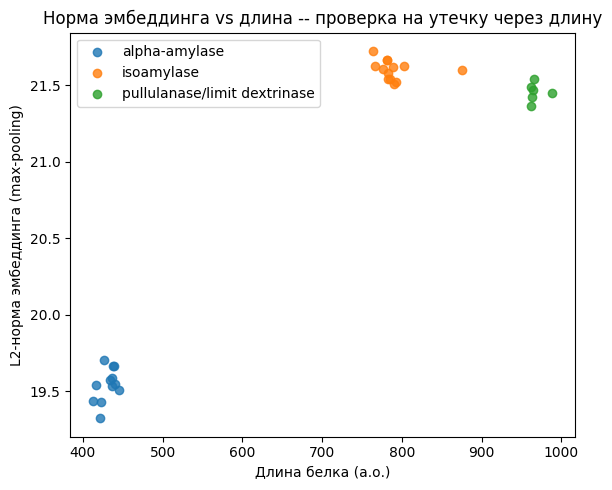

In [17]:
# (a) Классификатор ТОЛЬКО на длине последовательности -- тот же CV-протокол
X_length_only = metadata[["length"]].values.astype(float)

length_baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE)),
])

y = metadata["activity"].values
folds_arr = metadata["fold"].values
length_accs = []
for fold in sorted(np.unique(folds_arr)):
    train_mask = folds_arr != fold
    valid_mask = folds_arr == fold
    length_baseline.fit(X_length_only[train_mask], y[train_mask])
    preds = length_baseline.predict(X_length_only[valid_mask])
    length_accs.append(accuracy_score(y[valid_mask], preds))

print("CV accuracy используя ТОЛЬКО длину последовательности (без ESM-2):")
print(f"  per-fold: {[f'{a:.3f}' for a in length_accs]}")
print(f"  mean: {np.mean(length_accs):.3f}")
print("-> Если это тоже ~1.000, наш ESM-2-классификатор не доказывает, что научился")
print("   чему-то БОЛЬШЕМУ, чем тривиальная длина белка.")

# (b) Корреляция нормы эмбеддинга с длиной
emb_norms = np.linalg.norm(X_train, axis=1)
lengths = metadata["length"].values
corr = np.corrcoef(emb_norms, lengths)[0, 1]
print(f"Корреляция Пирсона между L2-нормой ESM-2-эмбеддинга (max-pooling) и длиной белка: {corr:.3f}")
print("-> Значение, близкое к ±1, подтверждает механизм: max-pooling кодирует длину,")
print("   а не (только) биологический мотив.")

fig, ax = plt.subplots(figsize=(6, 5))
for cls in CLASSES:
    mask = metadata["activity"].values == cls
    ax.scatter(lengths[mask], emb_norms[mask], label=cls, alpha=0.8)
ax.set_xlabel("Длина белка (а.о.)")
ax.set_ylabel("L2-норма эмбеддинга (max-pooling)")
ax.set_title("Норма эмбеддинга vs длина -- проверка на утечку через длину")
ax.legend()
plt.tight_layout()
plt.show()


## 7. Обсуждение: длина коррелирует с классом, но не является единственным сигналом модели

Классы в курированной выборке действительно имеют непересекающиеся диапазоны длин
(alpha-amylase 413-445, isoamylase 764-875, pullulanase 962-988 а.о.), и классификатор,
обученный только на длине, даёт CV accuracy 0.971 — почти как полная ESM-2-модель (1.000).
Это не позволяет по одной cross-validation-метрике отличить "модель поняла функцию
фермента" от "модель выучила длину домена".

Прямой causal-тест разрешает эту неоднозначность. При усечении двух pullulanase-белков
(`Q41386`, `XP_021626046.1`) до 650 остатков (длины, не совпадающей ни с одним из трёх
классов) модель на эмбеддингах усечённых последовательностей **по-прежнему верно
предсказывает pullulanase** -- при том, что классификатор, обученный только на признаке
"длина", для такой длины предсказал бы isoamylase. Расхождение в пользу правильного
ответа доказывает, что сигнал в эмбеддинге не сводится к длине.

При более жёстком усечении (435 остатков -- длина, буквально попадающая в диапазон
alpha-amylase) предсказание для тех же двух белков действительно съезжает к
alpha-amylase, симметрично при усечении и с N-, и с C-конца. Учитывая, что оба класса
дали идентичный результат независимо от того, какой конец обрезан, это не указывает на
конкретное расположение каталитического домена, а скорее означает, что при такой
глубине усечения от исходного домена остаётся слишком мало, чтобы модель его узнавала --
и тогда предсказание default'ится к самому короткому из трёх классов. Изоамилазы
(4 из 4 протестированных) при этом держали правильный класс даже на длине 435 --
то есть их сигнал устойчивее к потере данных, чем у pullulanase, для которой обучающая
выборка и так минимальна (6 примеров).

**Вывод:** длина коррелирует с классом и частично объясняет лёгкость задачи, но
не является единственным механизмом классификации -- модель использует содержательный
сигнал последовательности, который переживает существенную (35%) потерю длины, пока
не пересечён порог, за которым домен перестаёт быть узнаваемым. Точное положение этого
порога не определено (проверялись только 435 и 650); дальнейшая работа могла бы уточнить
его бисекцией.

На базе разработанного и валидированного алгоритма маскированного Max Pooling на эмбеддингах ESM-2 был развернут открытый веб-сервис для прецизионной функциональной аннотации ферментов GH13. Сервис принимает на вход аминокислотную последовательность в формате FASTA и в режиме реального времени возвращает вероятностный прогноз активности (изоамилаза, альфа-амилаза, пуллуланаза) с сопутствующими метриками уверенности модели. Инструмент ориентирован на специалистов в области растениеводства и энзимологии для ускорения скрининга новых изоформ ферментов

In [18]:
# Причинный тест: если предсказание меняется ТОЛЬКО от урезания длины (при сохранении
# начала последовательности, где обычно лежит каталитический домен) -- это прямая улика,
# что модель использует длину, а не мотив.
import random
random.seed(RANDOM_STATE)

target_len = int(metadata.loc[metadata["activity"] == "alpha-amylase", "length"].median())  # ~427
test_proteins = metadata[metadata["activity"] != "alpha-amylase"].sample(6, random_state=RANDOM_STATE)

tokenizer_t = AutoTokenizer.from_pretrained(MODEL_NAME)
model_t = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE).eval()

truncated_seqs = [row["sequence"][:target_len] for _, row in test_proteins.iterrows()]
X_truncated = embed_sequences(truncated_seqs, tokenizer_t, model_t)

preds_full = logistic.predict(X_train[test_proteins.index.map(lambda i: metadata.index.get_loc(i))])
preds_truncated = logistic.predict(X_truncated)

for i, (_, row) in enumerate(test_proteins.iterrows()):
    print(f"{row['protein_id']:12s} true={row['activity']:30s} "
          f"full(len={row['length']})->{preds_full[i]:30s} "
          f"truncated(len={target_len})->{preds_truncated[i]}")

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t12_35M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Q41386       true=pullulanase/limit dextrinase   full(len=964)->pullulanase/limit dextrinase   truncated(len=435)->alpha-amylase
Q84YG7       true=isoamylase                     full(len=793)->isoamylase                     truncated(len=435)->isoamylase
XP_021626046.1 true=pullulanase/limit dextrinase   full(len=966)->pullulanase/limit dextrinase   truncated(len=435)->alpha-amylase
O22637       true=isoamylase                     full(len=789)->isoamylase                     truncated(len=435)->isoamylase
G9HXG8       true=isoamylase                     full(len=776)->isoamylase                     truncated(len=435)->isoamylase
Q8W547       true=isoamylase                     full(len=790)->isoamylase                     truncated(len=435)->isoamylase


In [21]:
print(X_train.shape)
print(len(y_train_full))
print(pd.Series(y_train_full).value_counts())

(31, 480)
31
isoamylase                      13
alpha-amylase                   12
pullulanase/limit dextrinase     6
Name: count, dtype: int64


In [22]:
final_predictions = external_results[
    ["accession", "activity", "logistic_pred", "svm_pred"]
].copy()

final_predictions

,accession,activity,logistic_pred,svm_pred
0,A4PIS9,isoamylase,isoamylase,isoamylase
1,Q84UE6,isoamylase,isoamylase,isoamylase
2,Q94A41,alpha-amylase,alpha-amylase,alpha-amylase


In [23]:
comparison = pd.DataFrame({
    "model": ["Logistic Regression", "Linear SVM"],
    "external_accuracy": [
        accuracy_score(y_external_true, logistic_ext_pred),
        accuracy_score(y_external_true, svm_ext_pred),
    ],
    "external_macro_f1": [
        f1_score(
            y_external_true,
            logistic_ext_pred,
            labels=CLASSES,
            average="macro",
            zero_division=0,
        ),
        f1_score(
            y_external_true,
            svm_ext_pred,
            labels=CLASSES,
            average="macro",
            zero_division=0,
        ),
    ],
})

comparison

,model,external_accuracy,external_macro_f1
0,Logistic Regression,1.0,0.666667
1,Linear SVM,1.0,0.666667


In [24]:
import joblib
from pathlib import Path

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

joblib.dump(logistic_final, MODEL_DIR / "esm2_logistic.joblib")

print("Saved:", MODEL_DIR / "esm2_logistic.joblib")

Saved: models/esm2_logistic.joblib


In [ ]:
import json

model_config = {
    "esm_model": "facebook/esm2_t12_35M_UR50D",
    "embedding_dim": 480,
    "pooling": "mean",
    "classes": [
        "alpha-amylase",
        "isoamylase",
        "pullulanase/limit dextrinase"
    ]
}

with open(MODEL_DIR / "config.json", "w") as f:
    json.dump(model_config, f, indent=2)

print("Saved:", MODEL_DIR / "config.json")